### 최솟값 0 방지, 최댓값 1 방지 로직

C:\ProgramData\anaconda3\Lib\site-packages\pymongo\pyopenssl_context.py:348: CryptographyDeprecationWarning: Parsed a serial number which wasn't positive (i.e., it was negative or zero), which is disallowed by RFC 5280. Loading this certificate will cause an exception in a future release of cryptography.
  _crypto.X509.from_cryptography(x509.load_der_x509_certificate(cert))


⏳ 인프라 좌표 데이터를 로드 중...
⏳ 10000개 매물에 대해 '주요 지표 변별력 강화' 로직 적용 중...


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\User\AppData\Local\Temp\ipykernel_10424\4183431449.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Malgun Gothic.
  plt.savefig('세부조정 후 변별력 분석.png', dpi=300, bbox_inches='tight')
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


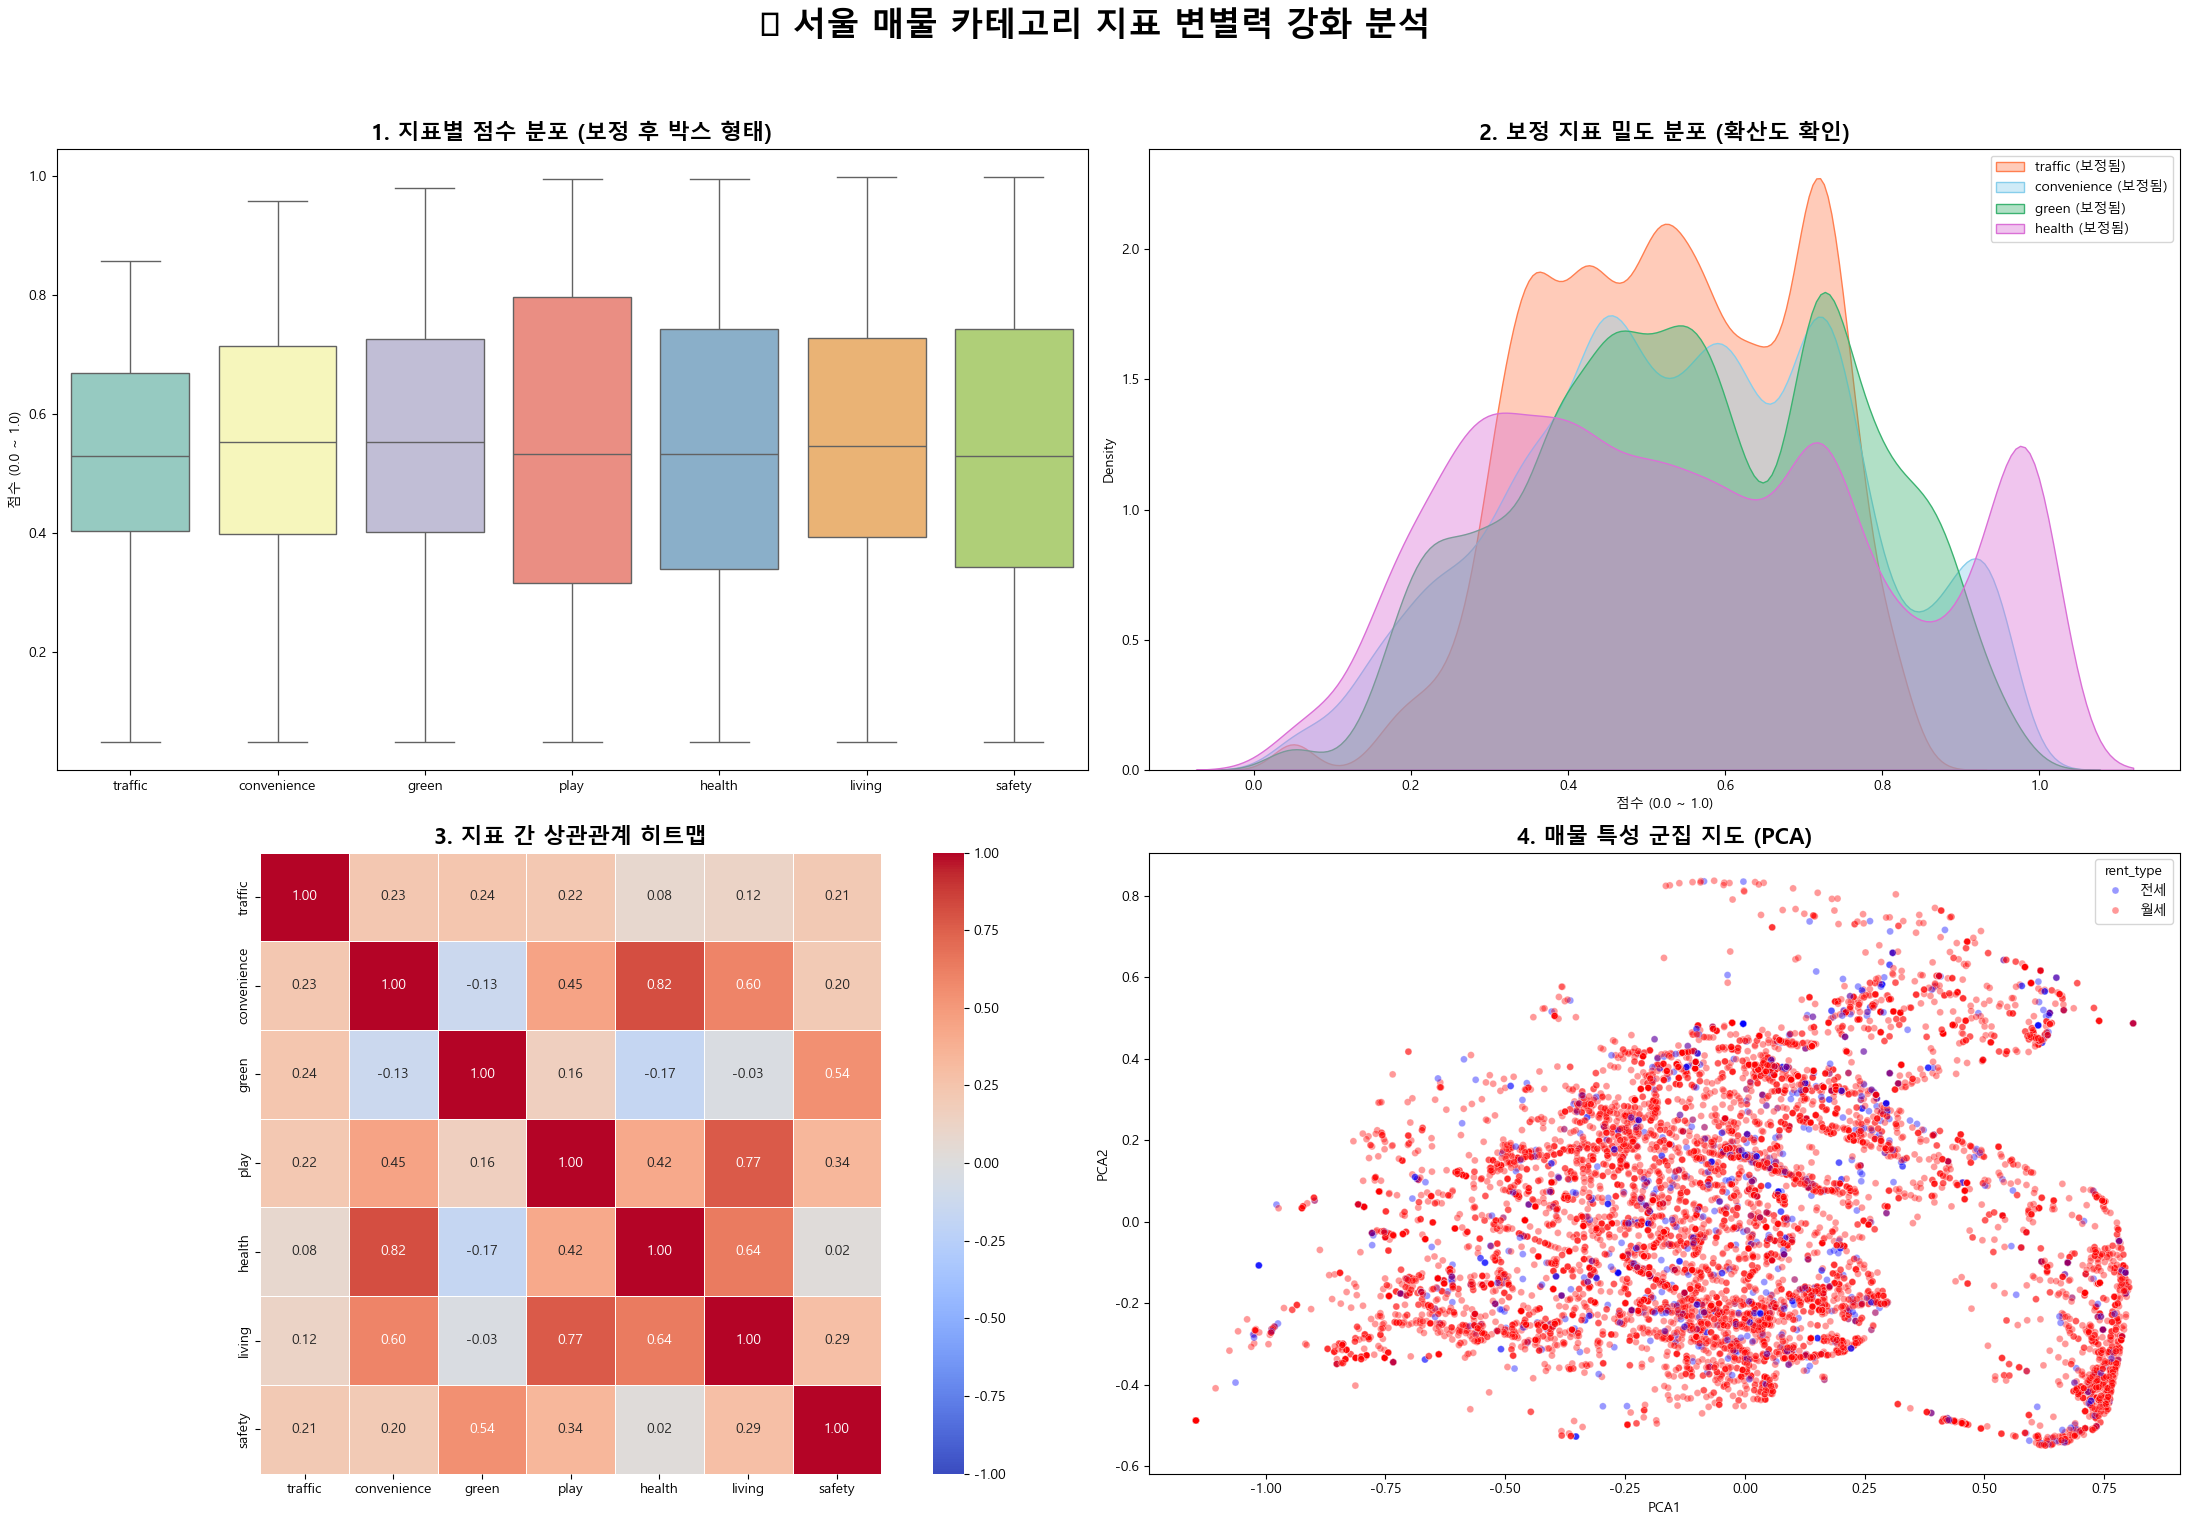

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import distance
from pymongo import MongoClient
from urllib.parse import quote_plus

# 1. 폰트 및 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. DB 연결
user = "JS"
password = quote_plus("Z26SdTRgqMadKJST") 
cluster_url = "cluster0.qpamvvh.mongodb.net"
uri = f"mongodb+srv://{user}:{password}@{cluster_url}/sesac_final?retryWrites=true&w=majority"

client = MongoClient(uri)
db = client['sesac_final']
infra_col = db['infra'] 
house_col = db['properties_test2']

# 3. 설정 및 민감도
infra_settings = {
    'traffic': {'bus_stop': 0.5, 'subway': 0.5},
    'convenience': {'convenience_store': 0.4, 'large_mart': 0.6},
    'green': {'park': 0.6, 'river': 0.1, 'mountain': 0.3},
    'play': {'cinema': 0.6, 'performance_hall': 0.4},
    'health': {'hospital': 0.9, 'clinic': 0.1},
    'living': {'library': 0.2, 'public_library': 0.3, 'bank': 0.5},
    'safety': {'police': 0.3, 'police_substation': 0.7}
}

category_scales = {
    'traffic': 0.005, 
    'convenience': 0.005, 
    'green': 0.012, 
    'play': 0.010, 
    'health': 0.005, 
    'living': 0.008, 
    'safety': 0.010
}

category_intensities = {
    'traffic': 0.0275, 
    'convenience': 0.045, 
    'green': 0.54, 
    'play': 0.105, 
    'health': 0.06, 
    'living': 0.065, 
    'safety': 0.30
}

# 변별력을 강화할 타겟 카테고리
expand_targets = ['traffic', 'convenience', 'green', 'health', 'living', 'safety']

# 4. 인프라 좌표 캐싱
infra_cache = {}
print("⏳ 인프라 좌표 데이터를 로드 중...")
for main_cat, sub_cats in infra_settings.items():
    for sub_name in sub_cats.keys():
        docs = list(infra_col.find({'sub_category': sub_name}))
        coords = []
        for d in docs:
            try:
                loc_data = d['location']['coordinates']
                if d['location']['type'] == 'LineString':
                    for coord in loc_data: coords.append([coord[1], coord[0]])
                else: coords.append([loc_data[1], loc_data[0]])
            except: continue
        if coords: infra_cache[sub_name] = np.array(coords)

# 5. 10,000개 매물 실시간 점수 시뮬레이션
processed_data = []
sample_limit = 10000 
print(f"⏳ {sample_limit}개 매물에 대해 '주요 지표 변별력 강화' 로직 적용 중...")

for house in house_col.find({"location": {"$exists": True}}).limit(sample_limit):
    try:
        h_coord = [house['location']['coordinates'][1], house['location']['coordinates'][0]]
        # 🌟 주소와 식별 정보를 row에 담음
        row = {
            'address': house.get('address', '주소 정보 없음'),
            'rent_type': house.get('rent_type', '알수없음')
        }
        
        for main_cat, sub_cats in infra_settings.items():
            total_main_score = 0
            current_scale = category_scales.get(main_cat, 0.008)
            intensity = category_intensities.get(main_cat, 0.07)
            
            for sub_name, weight in sub_cats.items():
                sub_coords = infra_cache.get(sub_name)
                if sub_coords is not None:
                    dists = distance.cdist([h_coord], sub_coords, 'euclidean')[0]
                    if sub_name == 'river':
                        min_dist = np.min(dists)
                        sum_val = np.exp(-min_dist / current_scale) if min_dist <= current_scale else 0
                    else:
                        sum_val = np.sum(np.exp(-dists / current_scale))
                    total_main_score += (sum_val * weight)

            # 1차 tanh 정규화
            norm_score = np.tanh(total_main_score * intensity)

            # 🔥 [변별력 강화] 타겟 지표에 대해 거듭제곱 양극화 적용
            if main_cat in expand_targets:
                # 양극화
                if norm_score > 0.6:
                    norm_score = 1 - (2 * (1 - norm_score))**2 / 2
                else:
                    norm_score = (2 * norm_score)**2 / 2

            # 🌟 [추가] 상위권 만점 방지 로직 (Soft-Cap)
            # 박스플롯 위치를 유지하기 위해 0.95 이상의 극상위권만 아주 미세하게 꺾음.
            if main_cat in ['play', 'health'] and norm_score > 0.95:
                # 0.95를 기점으로 그 이상의 증가폭을 tanh로 둔화시킴
                norm_score = 0.95 + (np.tanh((norm_score - 0.95) * 2) / 2.2)
                
            # 최솟값 보정: 0.05 미만으로 떨어지지 않도록 보정
            # 0점이었던 데이터도 0.05(5점)부터 시작.
            min_val = 0.05
            norm_score = min_val + (norm_score * (1 - min_val))
            
            row[main_cat] = float(np.clip(norm_score, 0, 1))
        processed_data.append(row)
    except: continue

df = pd.DataFrame(processed_data)
categories = list(infra_settings.keys())

# 6. 다차원 시각화
fig = plt.figure(figsize=(22, 16))
fig.suptitle('🏠 서울 매물 카테고리 지표 변별력 강화 분석', fontsize=24, fontweight='bold', y=0.98)

# [1] Boxplot: 4개 지표의 박스가 길게 늘어났는지 확인
ax1 = plt.subplot(2, 2, 1)
sns.boxplot(data=df[categories], palette='Set3', ax=ax1)
ax1.set_title('1. 지표별 점수 분포 (보정 후 박스 형태)', fontsize=16, fontweight='bold')
ax1.set_ylabel('점수 (0.0 ~ 1.0)')

# [2] KDE (밀도 함수): 뭉쳐있던 봉우리가 낮아지고 넓게 퍼졌는지 확인
ax2 = plt.subplot(2, 2, 2)
colors = ['coral', 'skyblue', 'mediumseagreen', 'orchid']
for cat, color in zip(expand_targets, colors):
    sns.kdeplot(data=df[cat], fill=True, label=f'{cat} (보정됨)', ax=ax2, color=color, alpha=0.4)
ax2.set_title('2. 보정 지표 밀도 분포 (확산도 확인)', fontsize=16, fontweight='bold')
ax2.set_xlabel('점수 (0.0 ~ 1.0)')
ax2.legend()

# [3] Heatmap: 지표 간 상관관계
ax3 = plt.subplot(2, 2, 3)
sns.heatmap(df[categories].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax3, fmt='.2f', square=True, linewidths=.5)
ax3.set_title('3. 지표 간 상관관계 히트맵', fontsize=16, fontweight='bold')

# [4] PCA: 매물 특성 군집 지도
ax4 = plt.subplot(2, 2, 4)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[categories].fillna(0))
df['PCA1'], df['PCA2'] = pca_result[:, 0], pca_result[:, 1]

# 변경된 부분: palette={'월세': 'red', '전세': 'blue'}
sns.scatterplot(x='PCA1', y='PCA2', hue='rent_type', data=df, alpha=0.4, palette={'월세': 'red', '전세': 'blue'}, ax=ax4, s=25)

ax4.set_title('4. 매물 특성 군집 지도 (PCA)', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('세부조정 후 변별력 분석.png', dpi=300, bbox_inches='tight')
plt.show()


### 검증

In [2]:
# 5. 데이터 추출 시 address 필드 포함 (이미 되어있다면 확인만 하세요)
# (기존 루프 안에서 row = {'address': house.get('address', '주소없음'), ...} 형태로 저장되어야 합니다)

# 7. 보정 결과 검증 루틴 (주소 출력 추가)
def verify_scores(original_df, category_name, top_n=5):
    print(f"\n{'═'*80}")
    print(f"📊 [ {category_name.upper()} ] 지표 심층 검증 (상위 vs 하위)")
    print(f"{'═'*80}")
    
    # 상위 N개 추출
    top_samples = original_df.nlargest(top_n, category_name)
    print(f"✅ [상위 {top_n} 매물 - 최적 입지]")
    for i, (_, row) in enumerate(top_samples.iterrows(), 1):
        # 주소(address)와 점수를 함께 출력
        addr = row.get('address', '주소 정보 없음')
        print(f"  {i}위. 점수: {row[category_name]:.4f} | 주소: {addr} ({row['rent_type']})")

    # 하위 N개 추출
    bottom_samples = original_df.nsmallest(top_n, category_name)
    print(f"\n❌ [하위 {top_n} 매물 - 입지 취약]")
    for i, (_, row) in enumerate(bottom_samples.iterrows(), 1):
        addr = row.get('address', '주소 정보 없음')
        print(f"  {i}위. 점수: {row[category_name]:.4f} | 주소: {addr} ({row['rent_type']})")

# 검증 실행
check_list = ['traffic', 'convenience', 'green', 'play', 'health', 'living', 'safety']
for cat in check_list:
    verify_scores(df, cat)

# 8. 통계적 요약 (가독성 개선 버전)
print("\n" + "═"*80)
print("📈 보정 후 지표별 기술 통계 요약 (세로 정렬)")
print("═"*80)

# 통계 항목 추출 및 Transpose(.T)
summary = df[categories].describe().loc[['min', '50%', 'mean', 'max', 'std']].T

# 컬럼명 변경 (50% -> median) 중앙값!
summary.rename(columns={'50%': 'median'}, inplace=True)

# 지수 표기법 방지 및 소수점 4자리 고정
pd.options.display.float_format = '{:.4f}'.format

print(summary)
print("═"*80)


════════════════════════════════════════════════════════════════════════════════
📊 [ TRAFFIC ] 지표 심층 검증 (상위 vs 하위)
════════════════════════════════════════════════════════════════════════════════
✅ [상위 5 매물 - 최적 입지]
  1위. 점수: 0.8565 | 주소: 서대문구 충정로2가 37-7 (월세)
  2위. 점수: 0.8538 | 주소: 서대문구 충정로2가 108 (월세)
  3위. 점수: 0.8440 | 주소: 마포구 창전동 3-77 (월세)
  4위. 점수: 0.8428 | 주소: 성동구 행당동 319-29 (월세)
  5위. 점수: 0.8418 | 주소: 마포구 창전동 118 (월세)

❌ [하위 5 매물 - 입지 취약]
  1위. 점수: 0.0500 | 주소: 중구 신흥동1가 34-27 (월세)
  2위. 점수: 0.0500 | 주소: 중구 중산동 1886-11 (월세)
  3위. 점수: 0.0500 | 주소: 중구 선린동 56-1 (월세)
  4위. 점수: 0.0500 | 주소: 중구 신흥동2가 54-8 (월세)
  5위. 점수: 0.0500 | 주소: 중구 신흥동2가 54-8 (월세)

════════════════════════════════════════════════════════════════════════════════
📊 [ CONVENIENCE ] 지표 심층 검증 (상위 vs 하위)
════════════════════════════════════════════════════════════════════════════════
✅ [상위 5 매물 - 최적 입지]
  1위. 점수: 0.9571 | 주소: 강남구 역삼동 736-24 (월세)
  2위. 점수: 0.9571 | 주소: 강남구 역삼동 736-24 (월세)
  3위. 점수: 0.9571 | 주소: 강남구 역삼동 736

### DB 업데이트 코드

In [3]:
import numpy as np
from scipy.spatial import distance
from pymongo import MongoClient, UpdateOne
from urllib.parse import quote_plus

# 1. DB 연결 (인증 정보 포함)
user = "JS"
password = quote_plus("Z26SdTRgqMadKJST") 
cluster_url = "cluster0.qpamvvh.mongodb.net"
uri = f"mongodb+srv://{user}:{password}@{cluster_url}/sesac_final?retryWrites=true&w=majority"

client = MongoClient(uri)
db = client['sesac_final']
infra_col = db['infra'] 
house_col = db['properties_test2']

# ---------------------------------------------------------
# 2. 점수 산정 및 변별력 강화 설정 
# ---------------------------------------------------------
infra_settings = {
    'traffic': {'bus_stop': 0.5, 'subway': 0.5},
    'convenience': {'convenience_store': 0.4, 'large_mart': 0.6},
    'green': {'park': 0.6, 'river': 0.1, 'mountain': 0.3},
    'play': {'cinema': 0.6, 'performance_hall': 0.4},
    'health': {'hospital': 0.9, 'clinic': 0.1},
    'living': {'library': 0.2, 'public_library': 0.3, 'bank': 0.5},
    'safety': {'police': 0.3, 'police_substation': 0.7}
}

category_scales = {
    'traffic': 0.005, 'convenience': 0.005, 'green': 0.012, 
    'play': 0.010, 'health': 0.005, 'living': 0.008, 'safety': 0.010
}

category_intensities = {
    'traffic': 0.0275, 'convenience': 0.045, 'green': 0.54, 
    'play': 0.105, 'health': 0.06, 'living': 0.065, 'safety': 0.30
}

# 변별력을 강화할 타겟 카테고리 (play 포함 모든 지표에 적용 가능)
expand_targets = ['traffic', 'convenience', 'green', 'health', 'living', 'safety', 'play']

# 3. 인프라 좌표 캐싱
infra_cache = {}
print("⏳ 인프라 좌표 데이터를 메모리에 로드 중...")

for main_cat, sub_cats in infra_settings.items():
    for sub_name in sub_cats.keys():
        docs = list(infra_col.find({'sub_category': sub_name}))
        coords = []
        for d in docs:
            try:
                loc_data = d['location']['coordinates']
                if d['location']['type'] == 'LineString':
                    for coord in loc_data: coords.append([coord[1], coord[0]])
                else:
                    coords.append([loc_data[1], loc_data[0]])
            except: continue
        if len(coords) > 0:
            infra_cache[sub_name] = np.array(coords)

# ---------------------------------------------------------
# 4. 메인 계산 및 벌크 업데이트 실행
# ---------------------------------------------------------
print("\n🚀 데이터 업데이트 시작...")

bulk_operations = []
batch_size = 1000  # 1000개 단위로 벌크 실행
count = 0

# 전체 데이터를 순회
for house in house_col.find({"location": {"$exists": True}}):
    try:
        h_id = house['_id']
        h_coord = [house['location']['coordinates'][1], house['location']['coordinates'][0]]
        category_scores = {}
        
        for main_cat, sub_cats in infra_settings.items():
            total_main_score = 0
            current_scale = category_scales.get(main_cat, 0.008)
            intensity = category_intensities.get(main_cat, 0.07)
            
            for sub_name, weight in sub_cats.items():
                sub_coords = infra_cache.get(sub_name)
                if sub_coords is not None:
                    dists = distance.cdist([h_coord], sub_coords, 'euclidean')[0]
                    if sub_name == 'river':
                        min_dist = np.min(dists)
                        sum_val = np.exp(-min_dist / current_scale) if min_dist <= current_scale else 0
                    else:
                        sum_val = np.sum(np.exp(-dists / current_scale))
                    total_main_score += (sum_val * weight)
            
            # 1차 tanh 정규화
            norm_score = np.tanh(total_main_score * intensity) 

            # 🔥 [변별력 강화] 분기점 0.6으로 통일
            if main_cat in expand_targets:
                if norm_score > 0.6:  # 0.7에서 0.6으로 수정
                    norm_score = 1 - (2 * (1 - norm_score))**2 / 2
                else:
                    norm_score = (2 * norm_score)**2 / 2

            # 🌟 [Soft-Cap 추가] 만점 방지 (시뮬레이션 로직 이식)
            if main_cat in ['play', 'health'] and norm_score > 0.92:
                norm_score = 0.92 + (np.tanh((norm_score - 0.92) * 2.5) * 0.07)
            
            # [최솟값 보정] 0.05 ~ 1.0 범위 확정
            min_val = 0.05
            final_score = min_val + (norm_score * (1 - min_val))
            
            # 소수점 4자리 저장
            category_scores[main_cat] = round(float(np.clip(final_score, 0, 1)), 4)

        # 벌크 명령 생성
        bulk_operations.append(
            UpdateOne({'_id': h_id}, {'$set': {'category_scores': category_scores}})
        )
        count += 1

        # 배치 사이즈 도달 시 DB 전송
        if len(bulk_operations) >= batch_size:
            house_col.bulk_write(bulk_operations)
            bulk_operations = []
            print(f"✅ {count}개 매물 처리 및 업데이트 완료...")

    except Exception as e:
        print(f"❌ 에러 발생 (ID: {house.get('_id')}): {e}")

# 남은 작업 처리
if bulk_operations:
    house_col.bulk_write(bulk_operations)
    
print(f"\n✨ 총 {count}개의 매물 점수 업데이트가 모두 완료되었습니다!")

C:\ProgramData\anaconda3\Lib\site-packages\pymongo\pyopenssl_context.py:348: CryptographyDeprecationWarning: Parsed a serial number which wasn't positive (i.e., it was negative or zero), which is disallowed by RFC 5280. Loading this certificate will cause an exception in a future release of cryptography.
  _crypto.X509.from_cryptography(x509.load_der_x509_certificate(cert))


⏳ 인프라 좌표 데이터를 메모리에 로드 중...

🚀 데이터 업데이트 시작...
✅ 1000개 매물 처리 및 업데이트 완료...
✅ 2000개 매물 처리 및 업데이트 완료...
✅ 3000개 매물 처리 및 업데이트 완료...
✅ 4000개 매물 처리 및 업데이트 완료...
✅ 5000개 매물 처리 및 업데이트 완료...
✅ 6000개 매물 처리 및 업데이트 완료...
✅ 7000개 매물 처리 및 업데이트 완료...
✅ 8000개 매물 처리 및 업데이트 완료...
✅ 9000개 매물 처리 및 업데이트 완료...
✅ 10000개 매물 처리 및 업데이트 완료...
✅ 11000개 매물 처리 및 업데이트 완료...
✅ 12000개 매물 처리 및 업데이트 완료...
✅ 13000개 매물 처리 및 업데이트 완료...
✅ 14000개 매물 처리 및 업데이트 완료...
✅ 15000개 매물 처리 및 업데이트 완료...
✅ 16000개 매물 처리 및 업데이트 완료...
✅ 17000개 매물 처리 및 업데이트 완료...
✅ 18000개 매물 처리 및 업데이트 완료...
✅ 19000개 매물 처리 및 업데이트 완료...
✅ 20000개 매물 처리 및 업데이트 완료...

✨ 총 20923개의 매물 점수 업데이트가 모두 완료되었습니다!
